# Notebook 1 (V4_3) — Production-Economy Model Setup

This notebook sets up the **two-country production OLG model** from
`Reference_draft/V4_3_production.tex`. It supersedes the V9 setup with
the following expository and substantive upgrades:

| Change | V9 | V4_3 |
|---|---|---|
| Equilibrium concept | *Recursive* competitive equilibrium | **Markov competitive equilibrium** (V4_3 `def_recursive_equilibrium`, line 664) |
| Within-country production symmetry | Assumption | **Derived Lemma** (V4_3 `lem_within_country_prod_symmetry`, lines 63–108) |
| Output decomposition | $Y_i = e_i + \mathcal D_i$ | $Y_i = e_i + \mathcal D_i - \mathcal I_i$ (V4_3 `country_output_income_identity`) |
| IPO transfer $\mathcal I_i$ | absent | $\mathcal I_i := (1-\varphi_i)H_i w_{H,i} = (N_{i,t+1}-N_i)q_i$ (V4_3 `country_ipo_transfer`) |
| Type aggregation | implicit | **Explicit type-specific portfolio problems** aggregated within each country (V4_3 §3.2, line 227+) |
| Primary bond unknown | $\theta$ (US household issuance, negative) | $\theta_{US}^*$ (RoW US-bond demand, positive); $\theta$ recovered by zero-net-supply clearing |
| Effective-kernel regularity | implicit | $\Psi_t = 1 - \lambda_t + \phi_t(1-\omega_t) > 0$ (V4_3 `ass_regular_kernel`, line 1145) |

The Theorem 1 bubble conditions (`thm_cond_1a`, `thm_cond_1b`, V4_3 line 1382–1389)
are unchanged in form; they are evaluated under the new Markov framing
in notebook 4.

> **Default calibration.** `ProductionParams()` now defaults to the **HKT-matched** calibration — the two-country embedding of the single-country numerical example of [HKT (2025), §4.2](https://arxiv.org/abs/2501.08215). It also enforces common world growth ($G_b=G_W$, V4_3 `ass_absorbing_stationary_equilibrium_selection`) by default, recalibrating $\nu_b$ (0.1 seed $\to \approx 0.082$); all other parameters stay HKT-literal. The original fast-growth example is recovered via `fast_growth_params()`.

**Bullet roadmap**

1. Markov state $s = (z, N_{US}, N_W)$ and primitive productivity maps.
2. Within-country production symmetry (Lemma).
3. Per-variety dividend yield $d_i/q_i$.
4. IPO transfer $\mathcal I_i$ and the V4_3 output identity.
5. Type-specific portfolio problems and aggregation.
6. Knowledge dynamics and common-world growth $G_b = G_W$.
7. Productivity schedules on $u$ and $b$ branches and the bubble exponent.
8. Markov competitive equilibrium and the reduced 7-equation system.
9. Summary of the V4_3 code surface.


In [1]:
# ── Activate project environment ──
using Pkg
Pkg.activate(".")

# ── Load the V4_3 production module ──
include("TwoCountryProductionOLG.jl")

using Plots, LaTeXStrings, Printf
gr()


  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/【Research】/Two_country_HKT/Codes`


Plots.GRBackend()

## 1. Markov State and Primitive Productivity Maps

The aggregate Markov state is
$$
s_t = (z_t, N_{US,t}, N_{W,t}) \in \{u, b\} \times \mathbb R_{++}^2,
$$
with $z_t$ following the transition matrix $\Pi$. V4_3
`ass_absorbing_bg_technology_primitives` (line 915) specifies the
country-$i$ factor-augmenting productivities on each branch:

US, $z = u$ (V4_3 eq. `US_u_productivity_primitives`):
$$
A_{X,US}(u, N) = \bar A_{X,US,u}\,N^{\xi_u},\qquad
A_{L,US}(u, N) = \bar A_{L,US,u}\,N^{\nu_u}.
$$

US, $z = b$ (V4_3 eq. `bg_us_primitives`):
$$
A_{X,US}(b, N) = \bar A_{X,US,b}\,N^{\nu_b},\qquad
A_{L,US}(b, N) = \bar A_{L,US,b}\,N^{\nu_b}.
$$

RoW (regime-invariant, V4_3 eq. `bg_w_primitives`):
$$
A_{X,W}(z, N) = \bar A_{X,W}\,N^{\xi_W},\qquad
A_{L,W}(z, N) = \bar A_{L,W}\,N^{\xi_W}.
$$

The **primitive US unbalanced-growth restrictions** (V4_3 eq. `psi_US_def`,
line 942) are
$$
\rho_{US} > 1, \qquad \xi_u > \nu_u > \nu_b \ge 0, \qquad
\psi_{US} := (\xi_u - \nu_u)(\rho_{US} - 1) > 0.
$$
The exponent $\psi_{US}$ controls the decay rate of $\varphi_{US,t}^u$
along the unbalanced branch.

| Parameter | Symbol | Default | Source |
|---|---|---|---|
| Discount factor | $\beta$ | 0.50 | saving propensity |
| CRRA curvature | $\gamma$ | 0.50 | $\gamma < 1$ aids bubble existence |
| Home-bias cost | $\kappa$ | 0.10 | |
| US equity target | $\bar\omega$ | 0.80 | |
| RoW equity target | $\bar\omega^*$ | 0.20 | |
| US-bond convenience | $\chi$ | 0.005 | |
| Bond issuance cost | $\eta$ | 0.01 | $\Upsilon(\theta) = -\log(1-\theta) + \theta^2/2$ |
| Regime persistence | $\pi$ | 0.70 | $P(z_{t+1}=u\mid z_t=u)$ |
| US CES $\alpha, \rho, \vartheta$ | | 0.50, 2.00, 0.50 | HKT $\alpha=1/2$, $\rho=2$, $\vartheta=1/2$ |
| US R&D, $H, L$ | | 0.20, 1.0, 1.0 | HKT $aH=0.2$ |
| RoW analogues | | 0.50, 2.00, 0.50; 0.20, 1.0, 1.0 | mirrors HKT balanced regime |
| Absorbing exponent | $\nu_b$ | 0.10 → ≈0.082 | recalibrated when `common_world_growth=true` |
| Unbalanced exponents | $\xi_u, \nu_u$ | 0.70, 0.20 | $\xi_u > \nu_u > \nu_b$ |
| RoW exponent | $\xi_W$ | 0.10 | HKT balanced exponent |


In [2]:
# ── Construct benchmark parameters (HKT-matched defaults) ──
# ProductionParams() defaults reproduce HKT's single-country numerical
# example (arXiv:2501.08215 §4.2); see TwoCountryProductionOLG.jl §1.
p = ProductionParams()

println("═══ Benchmark Calibration (HKT-matched, arXiv:2501.08215) ═══")
@printf("  β  = %.2f,  γ = %.2f\n", p.β, p.γ)
@printf("  κ  = %.4f, ω̄ = %.2f, ω̄* = %.2f\n", p.κ, p.ω̄, p.ω̄_star)
@printf("  χ  = %.4f, η = %.4f\n", p.χ, p.η)
@printf("  π  = %.2f\n", p.π_persist)
println()
println("  US: α=$(p.α_US), ρ=$(p.ρ_US), ϑ=$(p.ϑ_US), a=$(p.a_US), H=$(p.H_US), L=$(p.L_US)")
println("  W : α=$(p.α_W), ρ=$(p.ρ_W), ϑ=$(p.ϑ_W), a=$(p.a_W), H=$(p.H_W), L=$(p.L_W)")
println()
@printf("  ν_b = %.2f, ν_u = %.2f, ξ_u = %.2f, ξ_W = %.2f\n", p.ν_b, p.ν_u, p.ξ_u, p.ξ_W)
@printf("  N_US,0 = %.1f, N_W,0 = %.1f\n", p.N_US_0, p.N_W_0)
@printf("  T_max  = %d\n", p.T_max)
@printf("  common_world_growth = %s (V4_3 ass_absorbing_stationary_equilibrium_selection: G_b = G_W)\n",
        p.common_world_growth)

validate_params(p)
println("\n✓ V4_3 psi_US_def restrictions are satisfied (ρ_US > 1, ξ_u > ν_u > ν_b ≥ 0).")


═══ Benchmark Calibration (HKT-matched, arXiv:2501.08215) ═══
  β  = 0.50,  γ = 0.50
  κ  = 0.1000, ω̄ = 0.80, ω̄* = 0.20
  χ  = 0.0050, η = 0.0100
  π  = 0.70

  US: α=0.5, ρ=2.0, ϑ=0.5, a=0.2, H=1.0, L=1.0
  W : α=0.5, ρ=2.0, ϑ=0.5, a=0.2, H=1.0, L=1.0

  ν_b = 0.10, ν_u = 0.20, ξ_u = 0.70, ξ_W = 0.10
  N_US,0 = 1.0, N_W,0 = 1.0
  T_max  = 100
  common_world_growth = true (V4_3 ass_absorbing_stationary_equilibrium_selection: G_b = G_W)

✓ V4_3 psi_US_def restrictions are satisfied (ρ_US > 1, ξ_u > ν_u > ν_b ≥ 0).


## 2. Production Block and Within-Country Symmetry (Lemma)

In V4_3, within-country symmetry of intermediate firms is no longer an
assumption: it follows from the Dixit–Stiglitz aggregator, the common
skilled wage, and the unique monopoly-pricing rule.

**V4_3 Lemma `lem_within_country_prod_symmetry` (lines 63–108).**
Under the country-$i$ technology block, every intermediate firm
$j \in [0, N_{i,t}]$ charges $p_{i,t}(j) = w_{H,i,t}/\vartheta_i$ and
produces $x_{i,t}(j) = X_{i,t}/N_{i,t}$ where $X_{i,t} = \varphi_{i,t} H_i$
is the aggregate skilled-labour share allocated to intermediate
production.

The aggregated quantities reduce to:
- $Y_i = F_i(A_{X,i} \varphi_i H_i, A_{L,i} L_i)$ (CES output)
- $w_{H,i} = \vartheta_i F_{i,X} A_{X,i}$ (skilled wage, V4_3 `country_factor_prices`)
- $w_{L,i} = F_{i,L} A_{L,i}$ (unskilled wage)
- $q_i = w_{H,i}/(a_i N_i)$ (per-variety stock price, V4_3 `country_Q_from_wage` & free entry)
- $d_i = (1-\vartheta_i)/\vartheta_i \cdot w_{H,i} \cdot (X_i / N_i)$ (per-variety dividend, V4_3 `country_dividend_formula`)
- $e_i = w_{H,i} H_i + w_{L,i} L_i$ (aggregate young-agent budget income, V4_3 `country_labor_income`)

The module's `compute_production` implements all six objects directly
from the Lemma-aggregated form.


In [3]:
# ── Inspect US block at sample (φ, N) values, both regimes ──
println("═══ US production block: regime = :u (unbalanced) ═══")
for (φ, N) in [(0.5, 1.0), (0.3, 5.0), (0.1, 50.0)]
    b = us_block(p, :u, φ, N)
    @printf("  φ=%.2f N=%5.1f → Y=%.3f w_H=%.4f q=%.4f d=%.4f e=%.4f I=%.4f\n",
            φ, N, b.Y, b.w_H, b.q, b.d, b.e, b.I)
end
println()
println("═══ US production block: regime = :b (absorbing) ═══")
for (φ, N) in [(0.5, 1.0), (0.5, 5.0), (0.5, 50.0)]
    b = us_block(p, :b, φ, N)
    @printf("  φ=%.2f N=%5.1f → Y=%.3f w_H=%.4f q=%.4f d=%.4f e=%.4f I=%.4f\n",
            φ, N, b.Y, b.w_H, b.q, b.d, b.e, b.I)
end
println()
println("═══ RoW production block ═══")
for (φ, N) in [(0.5, 1.0), (0.5, 5.0), (0.5, 50.0)]
    b = row_block(p, φ, N)
    @printf("  φ=%.2f N=%5.1f → Y=%.3f w_H=%.4f q=%.4f d=%.4f e=%.4f I=%.4f\n",
            φ, N, b.Y, b.w_H, b.q, b.d, b.e, b.I)
end


═══ US production block: regime = :u (unbalanced) ═══
  φ=0.50 N=  1.0 → Y=1.667 w_H=0.2778 q=1.3889 d=0.1389 e=1.6667 I=0.1389
  φ=0.30 N=  5.0 → Y=2.401 w_H=0.5192 q=0.5192 d=0.0312 e=2.6092 I=0.3635
  φ=0.10 N= 50.0 → Y=3.832 w_H=2.3737 q=0.2374 d=0.0047 e=5.7305 I=2.1363

═══ US production block: regime = :b (absorbing) ═══
  φ=0.50 N=  1.0 → Y=1.667 w_H=0.2778 q=1.3889 d=0.1389 e=1.6667 I=0.1389
  φ=0.50 N=  5.0 → Y=1.958 w_H=0.3263 q=0.3263 d=0.0326 e=1.9577 I=0.1631
  φ=0.50 N= 50.0 → Y=2.465 w_H=0.4108 q=0.0411 d=0.0041 e=2.4646 I=0.2054

═══ RoW production block ═══
  φ=0.50 N=  1.0 → Y=1.667 w_H=0.2778 q=1.3889 d=0.1389 e=1.6667 I=0.1389
  φ=0.50 N=  5.0 → Y=1.958 w_H=0.3263 q=0.3263 d=0.0326 e=1.9577 I=0.1631
  φ=0.50 N= 50.0 → Y=2.465 w_H=0.4108 q=0.0411 d=0.0041 e=2.4646 I=0.2054


## 3. Per-Variety Dividend Yield

From V4_3 eq. `country_dividend_yield`:
$$
\frac{d_{i,t}}{q_{i,t}} = a_i \cdot \frac{1-\vartheta_i}{\vartheta_i} \cdot \varphi_{i,t} H_i.
$$

This is the key object behind Theorem 1 condition (1a)
(V4_3 `thm_cond_1a`, line 1385):
as $\varphi_{US,t}^u$ declines along the unbalanced branch, the
per-variety dividend yield falls geometrically, so the price-dividend
ratio $q_{US}/d_{US}$ rises.


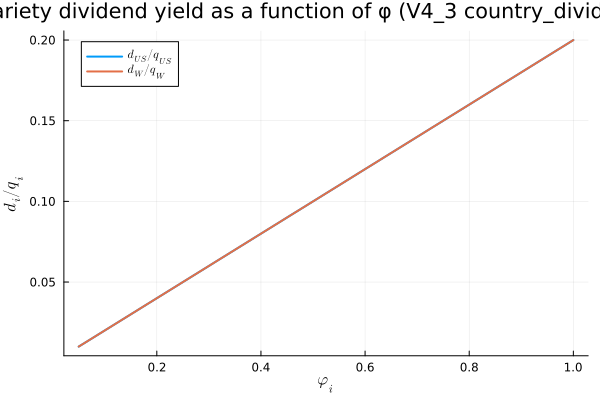

In [4]:
# ── Plot d/q vs φ for both countries ──
φs = 0.05:0.01:1.0
dq_US = [p.a_US * (1 - p.ϑ_US) / p.ϑ_US * φ * p.H_US for φ in φs]
dq_W  = [p.a_W  * (1 - p.ϑ_W)  / p.ϑ_W  * φ * p.H_W  for φ in φs]

plot(φs, dq_US, lw=2, label=L"d_{US}/q_{US}",
     xlabel=L"\varphi_i", ylabel=L"d_i/q_i",
     title="Per-variety dividend yield as a function of φ (V4_3 country_dividend_yield)")
plot!(φs, dq_W, lw=2, label=L"d_W/q_W")


## 4. IPO Transfer and Output Decomposition (V4_3)

**V4_3 eq. `country_ipo_transfer` (line 211–214).** The R&D workers'
income is paid by buyers of newly issued equity claims, so it is not
part of current final-good output. Define
$$
\mathcal I_{i,t} := (1-\varphi_{i,t}) H_i w_{H,i,t} = (N_{i,t+1} - N_{i,t}) q_{i,t}.
$$
The second equality uses the knowledge law
$N_{i,t+1} - N_{i,t} = a_i(1-\varphi_{i,t}) H_i N_{i,t}$ and the
free-entry IPO price $w_{H,i,t} = a_i N_{i,t} q_{i,t}$.

**V4_3 eq. `country_output_income_identity` (line 217–222).** Final-good
output decomposes as
$$
Y_{i,t} = \varphi_{i,t} H_i w_{H,i,t} + w_{L,i,t} L_i + \mathcal D_{i,t}
       = e_{i,t} + \mathcal D_{i,t} - \mathcal I_{i,t}.
$$
The corrected identity replaces V9's $Y_i = e_i + \mathcal D_i$ by
subtracting the IPO transfer. Goods-market clearing
(V4_3 eq. `goods_clear_mod`, line 610) is
$$
C_{y,t}+C^*_{y,t}+C_{o,t}+C^*_{o,t}
 = e_{US,t}+e_{W,t}+\mathcal D_{US,t}+\mathcal D_{W,t}
 - \mathcal I_{US,t}-\mathcal I_{W,t}.
$$

The next cell verifies the identity at sample $(\varphi, N)$ pairs.


In [5]:
# ── V4_3 output-identity check (Y = e + N·d − I) ──
for (regime, φ, N) in [(:u, 0.5, 1.0), (:u, 0.3, 5.0),
                       (:b, 0.5, 1.0), (:b, 0.5, 50.0)]
    b = us_block(p, regime, φ, N)
    Y_alt = b.e + N * b.d - b.I
    I_alt = (G_N_US(p, φ) - 1) * N * b.q
    @printf("[US/%s] φ=%.2f N=%5.1f  Y=%.4e  Y_alt=%.4e  ΔY=%+.1e   I=%.4e  ΔI=%+.1e\n",
            regime, φ, N, b.Y, Y_alt, b.Y - Y_alt, b.I, b.I - I_alt)
end
println("\nBoth residuals should be at machine epsilon: this is the V4_3 algebraic identity, not a calibration.")


[US/u] φ=0.50 N=  1.0  Y=1.6667e+00  Y_alt=1.6667e+00  ΔY=-2.2e-16   I=1.3889e-01  ΔI=-1.1e-16
[US/u] φ=0.30 N=  5.0  Y=2.4015e+00  Y_alt=2.4015e+00  ΔY=+0.0e+00   I=3.6347e-01  ΔI=+2.2e-16
[US/b] φ=0.50 N=  1.0  Y=1.6667e+00  Y_alt=1.6667e+00  ΔY=-2.2e-16   I=1.3889e-01  ΔI=-1.1e-16
[US/b] φ=0.50 N= 50.0  Y=2.4646e+00  Y_alt=2.4646e+00  ΔY=+0.0e+00   I=2.0538e-01  ΔI=-1.9e-16

Both residuals should be at machine epsilon: this is the V4_3 algebraic identity, not a calibration.


## 5. Type-Specific Portfolio Problems and Aggregation

**V4_3 §3.2 (line 227+).** Portfolio problems are specified at the
type level: each country has a mass $H_i$ of skilled and $L_i$ of
unskilled young agents, with type-$a$ income
$y_{a,US,t} \in \{w_{H,US,t}, w_{L,US,t}\}$. Because preferences are
homogeneous and all types within a country face the same returns and
portfolio-share frictions, the optimal portfolio shares are common
across types within a country.

Aggregation (V4_3 eq. `US_saving_rule_bond_cost`, lines 320–324):
$$
A_t := \sum_{a} m_{a,US} A^{US}_{a,t} = \beta e_{US,t},
\qquad
C_{y,t} := \sum_{a} m_{a,US} c^{US}_{y,a,t} = (1-\beta) e_{US,t}.
$$
The aggregate FOCs and the asset-pricing kernel
$\mathcal K_{t,t+1} = R_{A,t+1}^{-\gamma}/E[R_{A,t+1}^{1-\gamma}]$
are identical to the V9 reduced form, but V4_3 makes the type-level
derivation explicit. The code implements the country-aggregated FOCs
in `bgp_residual!` and `u_residual!`.

The RoW block follows the same structure with a single common
SDF and the additional convenience-yield term
$\chi \log A^W_{a,t}$, giving
$A^W_{a,t} = \frac{\beta+\chi}{1+\chi} y_{a,W,t}$
(V4_3 line 497) and aggregating to
$A^* = \frac{\beta+\chi}{1+\chi} e_W$.


In [6]:
# ── Aggregate-saving sanity check (V4_3 US_saving_rule_bond_cost) ──
for (regime, φ, N) in [(:b, 0.5, 1.0), (:u, 0.3, 5.0)]
    us = us_block(p, regime, φ, N)
    A_US = p.β * us.e
    @printf("[US/%s] e_US=%.4f  A_US (β·e_US) = %.4f\n", regime, us.e, A_US)
end
rw = row_block(p, 0.7, 1.0)
A_W_star = (p.β + p.χ) / (1 + p.χ) * rw.e
@printf("[RoW]    e_W=%.4f  A^*_W ((β+χ)/(1+χ)·e_W) = %.4f\n", rw.e, A_W_star)


[US/b] e_US=1.6667  A_US (β·e_US) = 0.8333
[US/u] e_US=2.6092  A_US (β·e_US) = 1.3046
[RoW]    e_W=1.6875  A^*_W ((β+χ)/(1+χ)·e_W) = 0.8479


## 6. Knowledge Dynamics and Common-World Growth

Knowledge accumulates according to
$$
N_{i,t+1} = G_{N,i}(\varphi_{i,t}) N_{i,t},\qquad
G_{N,i}(\varphi) = 1 + a_i(1-\varphi) H_i,
$$
(V4_3 eq. `country_knowledge_law`). The induced aggregate growth
rates on the absorbing branch are
$$
G_b = G_{N,US,b}^{\nu_b}, \qquad G_W = G_{N,W,b}^{\xi_W}.
$$

**V4_3 Equilibrium-selection assumption
`ass_absorbing_stationary_equilibrium_selection` (line 947–984).**
The selected absorbing stationary solution satisfies the
common-growth condition
$$
G_b = G_W.
$$
This couples the US and RoW production blocks: one of $\nu_b$ or
$\xi_W$ becomes a derived parameter. The module implements this via
`common_world_growth=true`, which iteratively adjusts $\nu_b$
through `calibrate_common_growth`.


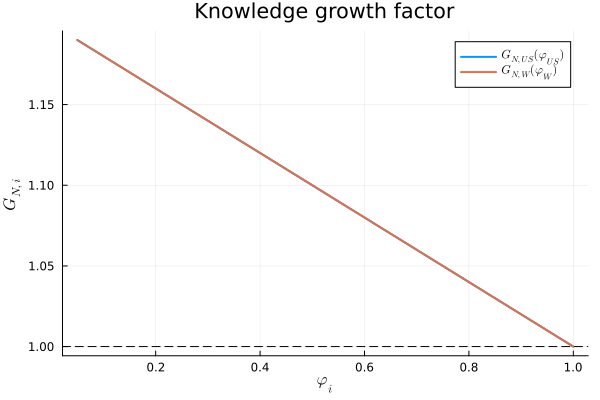

In [7]:
# ── Knowledge growth factor as a function of φ ──
G_US_curve = [G_N_US(p, φ) for φ in φs]
G_W_curve  = [G_N_W(p,  φ) for φ in φs]
plot(φs, G_US_curve, lw=2, label=L"G_{N,US}(\varphi_{US})",
     xlabel=L"\varphi_i", ylabel=L"G_{N,i}",
     title="Knowledge growth factor")
plot!(φs, G_W_curve, lw=2, label=L"G_{N,W}(\varphi_W)")
hline!([1.0], ls=:dash, color=:black, label="")


## 7. Productivity Schedules on $u$ and $b$ Branches; Bubble Exponent

The CES with $\rho_{US} > 1$ implies that the asymmetric factor-augmentation
on the $u$ branch ($\xi_u > \nu_u$) makes the labour-augmented input
asymptotically binding, **bounding** the equilibrium labour share by
$$
\varphi_{US,t}^u \lesssim N_{US,t}^{-\psi_{US}/\rho_{US}},
\qquad
\psi_{US} = (\xi_u - \nu_u)(\rho_{US} - 1),
$$
(V4_3 eq. `psi_US_def` and Lemma `lem_prod_orders`, eq. `phi_u_upper_order`).
This is a one-sided **upper** bound — the draft proves only $\lesssim$, because
$\varphi_{US,t}^u$ is an equilibrium object, not a primitive. Hence the
per-variety dividend yield $d^u/q^u \lesssim N_{US,t}^{-\psi_{US}/\rho_{US}}$
collapses (at least) geometrically in $N_{US,t}$. Numerically the decay
exponent approaches $\psi_{US}/\rho_{US}$ from below (see `07_v9_assumption_checks.ipynb`).

V4_3 production-side decay exponent (eq. psi_US_def):
  ψ_US = (ξ_u - ν_u)(ρ_US - 1) = (0.70 - 0.20)(2.00 - 1) = 0.5000
  φ_US,t^u ≲ N_US,t^(-ψ_US/ρ_US) = N_US,t^(-0.2500)   [upper bound, lem_prod_orders]
  ⇒ d^u/q^u ≲ φ_US,t^u ≲ N_US,t^(-0.2500)


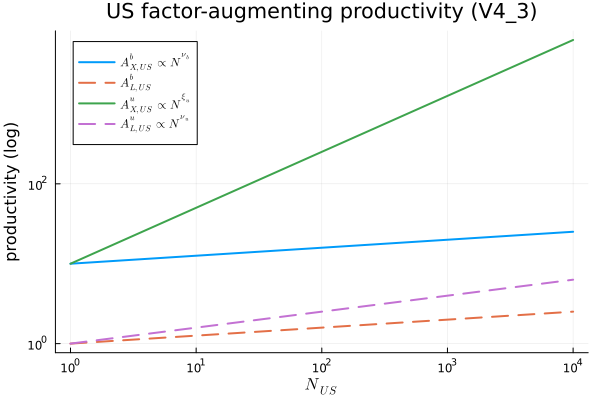

In [8]:
# ── Bubble decay exponent and productivity panel ──
ψ_US = (p.ξ_u - p.ν_u) * (p.ρ_US - 1)
decay = ψ_US / p.ρ_US

@printf("V4_3 production-side decay exponent (eq. psi_US_def):\n")
@printf("  ψ_US = (ξ_u - ν_u)(ρ_US - 1) = (%.2f - %.2f)(%.2f - 1) = %.4f\n",
        p.ξ_u, p.ν_u, p.ρ_US, ψ_US)
# V4_3 lem_prod_orders proves only the one-sided UPPER bound (≲), not ∝/≍.
@printf("  φ_US,t^u ≲ N_US,t^(-ψ_US/ρ_US) = N_US,t^(%.4f)   [upper bound, lem_prod_orders]\n", -decay)
@printf("  ⇒ d^u/q^u ≲ φ_US,t^u ≲ N_US,t^(%.4f)\n", -decay)

# Productivity along absorbing and unbalanced regimes (these ARE primitive, exact ∝)
Ns = 10 .^ range(0, 4, length=200)
AX_b = [productivity_US(p, :b, N)[1] for N in Ns]
AL_b = [productivity_US(p, :b, N)[2] for N in Ns]
AX_u = [productivity_US(p, :u, N)[1] for N in Ns]
AL_u = [productivity_US(p, :u, N)[2] for N in Ns]

p1 = plot(Ns, AX_b, lw=2, label=L"A_{X,US}^b \propto N^{\nu_b}", xscale=:log10, yscale=:log10,
          xlabel=L"N_{US}", ylabel="productivity (log)", title="US factor-augmenting productivity (V4_3)")
plot!(p1, Ns, AL_b, lw=2, label=L"A_{L,US}^b", ls=:dash)
plot!(p1, Ns, AX_u, lw=2, label=L"A_{X,US}^u \propto N^{\xi_u}")
plot!(p1, Ns, AL_u, lw=2, label=L"A_{L,US}^u \propto N^{\nu_u}", ls=:dash)
p1

## 8. Markov Competitive Equilibrium and the Reduced 7-Equation System

**V4_3 Definition `def_recursive_equilibrium` (line 664).** A Markov
competitive equilibrium is a collection of measurable functions of
$s = (z, N_{US}, N_W)$ — prices, returns, production and innovation
choices, and household portfolio choices — satisfying production
optimality and free entry, household optimization, asset-market
clearing, and the goods-market identity. The state transition is
generated by
$$
\Gamma(s, z') = \bigl(z', G_{N,US}(\varphi_{US}(s))\,N_{US},\,
G_{N,W}(\varphi_W(s))\,N_W\bigr),
$$
(V4_3 eq. `recursive_next_state`).

**Reduced state-by-state characterization (V4_3 lines 745–882).** At
each state $s$, the equilibrium reduces to a 7-vector
$$
x(s) = (\varphi_{US}, \varphi_W, \omega, \theta_{US}^*, \omega^*, R_f, R_f^W)
$$
solving the system

|   | Equation | V4_3 label |
|---|---|---|
| F[1] | stock-market value clearing, US | `intratemporal_phi_US` |
| F[2] | stock-market value clearing, RoW | `intratemporal_phi_W` |
| F[3] | US $\omega$ FOC | `intratemporal_omega_US` |
| F[4] | US $\theta$ FOC (on recovered $\theta$) | `intratemporal_theta_US` |
| F[5] | RoW $\omega^*$ FOC | `intratemporal_omega_W` |
| F[6] | RoW $\theta_W^*$ pricing ($R_f^W = R_p^*$) | `intratemporal_thetaW` |
| F[7] | RoW $\theta_{US}^*$ clearing with $\chi$ wedge | `intratemporal_thetaUS` |

The remaining bond shares are **recovered** state by state from
zero-net-supply bond clearing (V4_3 lines 800–802):
$$
\theta_W^*(s) = 0,
\qquad
\theta(s) = -\theta_{US}^*(s) \frac{A^*(s, x(s))}{A(s, x(s))},
$$
with $A(s,x) = \beta e_{US}(s, \varphi_{US})$ and
$A^*(s,x) = \frac{\beta+\chi}{1+\chi}\,e_W(s, \varphi_W)$.

The module's `bgp_residual!` and `u_residual!` evaluate exactly this
system; the constrained parameterization $\theta_{US}^* = \exp(g_4) > 0$
enforces positive RoW US-bond demand by construction.


In [9]:
# ── Quick BGP sanity check (cheap, but exercises the full reduced system) ──
bgp_demo = solve_bgp_at(p, p.N_US_0, p.N_W_0)
@printf("BGP solver at (N_US,0, N_W,0):  converged=%s   ‖F‖=%.2e\n",
        bgp_demo.converged, bgp_demo.residual_norm)
@printf("  φ_US=%.4f  φ_W=%.4f  ω=%.4f  ω*=%.4f\n",
        bgp_demo.φ_US, bgp_demo.φ_W, bgp_demo.ω, bgp_demo.ω_star)
@printf("  θ_US^* (primary, > 0) = %+.4f\n", bgp_demo.θ_US_star)
@printf("  θ      (recovered)    = %+.4f\n", bgp_demo.θ)
@printf("  R_f = %.4f   R_f^W = %.4f\n", bgp_demo.R_f, bgp_demo.R_f_W)
@printf("  Ψ (V4_3 ass_regular_kernel) = %.4f   I_US = %.4e   I_W = %.4e\n",
        bgp_demo.Psi, bgp_demo.I_US, bgp_demo.I_W)

# Verify recovery: θ + θ_US^* · A^* / A = 0
A    = p.β * bgp_demo.e_US
As   = (p.β + p.χ) / (1 + p.χ) * bgp_demo.e_W
@printf("\nRecovery check |θ + θ_US^*·A^*/A| = %.2e\n",
        abs(bgp_demo.θ + bgp_demo.θ_US_star * As / A))


BGP solver at (N_US,0, N_W,0):  converged=true   ‖F‖=1.59e-12
  φ_US=0.6614  φ_W=0.7275  ω=0.6001  ω*=0.1706
  θ_US^* (primary, > 0) = +0.7433
  θ      (recovered)    = -0.7515
  R_f = 1.0734   R_f^W = 1.0879
  Ψ (V4_3 ass_regular_kernel) = 0.9882   I_US = 5.8421e-02   I_W = 3.9794e-02

Recovery check |θ + θ_US^*·A^*/A| = 0.00e+00


## Summary

- **Markov competitive equilibrium** (V4_3 Definition `def_recursive_equilibrium`)
  formalizes the production economy as a reduced 7-equation system in
  $x = (\varphi_{US}, \varphi_W, \omega, \theta_{US}^*, \omega^*, R_f, R_f^W)$.
- The bond shares $\theta$ and $\theta_W^*$ are **recovered** by
  zero-net-supply clearing, not solved for.
- The **IPO transfer** $\mathcal I_i = (1-\varphi_i) H_i w_{H,i}$ is now a
  primitive accounting object; the V4_3 output identity
  $Y_i = e_i + \mathcal D_i - \mathcal I_i$ corrects the V9 form
  $Y_i = e_i + \mathcal D_i$.
- **Within-country symmetry** is a derived Lemma (V4_3
  `lem_within_country_prod_symmetry`), not a primitive assumption.
- **Effective-kernel regularity** $\Psi_t > 0$ (V4_3 `ass_regular_kernel`)
  is required for Theorem 1; the module's `compute_psi` and
  `ProductionDiagnostics.psi_min/psi_ok` track it along the u-branch.
- The bubble exponent $\psi_{US} = (\xi_u - \nu_u)(\rho_{US} - 1) > 0$
  (V4_3 eq. `psi_US_def`) **bounds** the decay
  $\varphi_{US,t}^u \lesssim N^{-\psi_{US}/\rho_{US}}$ (a one-sided upper
  bound, V4_3 Lemma `lem_prod_orders`).

Next notebook: solve the **absorbing-regime stationary normalized
equilibrium** (BGP) and verify the common-growth selection
$G_b = G_W$ from V4_3 `ass_absorbing_stationary_equilibrium_selection`.